<a href="https://colab.research.google.com/github/pxtroniwnl/barcelona-de-indias-time-serie/blob/main/humedad_del_aire_IDEAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Humedad del aire — estaciones IDEAM cercanas al ROI de la laguna

**Fuente:** CSV del IDEAM, departamento de Bolívar, sensores de humedad relativa del aire a 2 m.
**Objetivo:** Identificar las 2 estaciones más cercanas al ROI de la laguna Barcelona de Indias, limpiar y homogenizar sus series de humedad del aire, generar diagnósticos de cobertura y ciclo diario medio, y exportar los datos para análisis posteriores.

## 1. Configuración

In [1]:
import csv
import io
import math
from pathlib import Path

import folium
from folium.plugins import Fullscreen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rutas locales
RUTA_CSV = Path("data/ideam/Humedad_del_Aire_20260818_SOLO_BOLIVAR.csv")

# Formato de fecha del IDEAM
FORMATO_FECHA = "%Y %b %d %I:%M:%S %p"

# Conservar como texto para no perder ceros a la izquierda en códigos
DTYPES_TEXTO = {"CodigoEstacion": "string", "CodigoSensor": "string"}

COLS_TEXTO = [
    "CodigoEstacion", "CodigoSensor", "NombreEstacion", "Departamento",
    "Municipio", "ZonaHidrografica", "DescripcionSensor", "UnidadMedida",
]

# Rango físicamente plausible para humedad relativa del aire en el Caribe colombiano (%)
# Valores < 5.0% corresponden a desconexiones o fallos instrumentales
RANGO_HUMEDAD_VALIDO = (5.0, 100.0)

# ROI de la laguna Barcelona de Indias (longitud, latitud)
ROI_COORDS = [
    [-75.476052, 10.517524],
    [-75.476117, 10.518747],
    [-75.473158, 10.519223],
    [-75.470516, 10.525108],
    [-75.469572, 10.524876],
    [-75.471686, 10.518916],
    [-75.468394, 10.517219],
    [-75.468952, 10.516459],
]

FACTORES = [1, 2, 3, 4]
COLORES_CAJA = {1: "red", 2: "orange", 3: "gold", 4: "green"}
N_ESTACIONES = 2
TOL_SITIO = 3  # decimales de redondeo para colapsar sitios físicos (≈ 110 m)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 2. Carga del CSV crudo

Se carga directamente utilizando el motor C optimizado de `pandas`.
`df_raw` **no se modifica nunca**.

In [2]:
def cargar_crudo(ruta: Path) -> pd.DataFrame:
    """Carga el CSV del IDEAM de forma directa y eficiente en memoria."""
    return pd.read_csv(ruta, dtype=DTYPES_TEXTO, encoding="utf-8-sig", low_memory=False)


df_raw = cargar_crudo(RUTA_CSV)
print(f"{len(df_raw):,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

1,238,283 filas × 12 columnas


,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,0029015000,0027,2016 Oct 20 02:00:00 AM,100.0,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Humedad del aire 2 mt,%
1,0029015000,0027,2016 May 07 02:00:00 AM,100.0,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Humedad del aire 2 mt,%
2,0029015040,0027,2013 Sep 08 10:00:00 AM,66.0,CARMEN DE BOLIVAR - AUT,BOLIVAR,EL CARMÉN DE BOLÍVAR,BAJO MAGDALENA,9.715750,-75.106417,Humedad del aire 2 mt,%


In [3]:
# Diagnóstico del crudo: valores categóricos, tipos de sensores y unidades
for col in ["UnidadMedida", "DescripcionSensor", "CodigoSensor", "Departamento"]:
    vals = sorted(df_raw[col].dropna().unique().tolist())
    print(f"{col:20s} ({len(vals):>3}): {vals[:6]}{' …' if len(vals) > 6 else ''}")

print()
print("Distribución por tipo de sensor:")
print(df_raw["DescripcionSensor"].value_counts())
print()
print(df_raw.dtypes)

UnidadMedida         (  1): ['%']
DescripcionSensor    (  3): ['GPRS - HUMEDAD DEL AIRE A 2 m', 'HUMEDAD DEL SUELO A 1 m Ó MAS', 'Humedad del aire 2 mt']


CodigoSensor         (  2): ['0027', '0028']
Departamento         (  3): ['BOLIVAR', 'BOLÍVAR', 'Bolivar']

Distribución por tipo de sensor:


DescripcionSensor
GPRS - HUMEDAD DEL AIRE A 2 m    671133
Humedad del aire 2 mt            428613
HUMEDAD DEL SUELO A 1 m Ó MAS    138537
Name: count, dtype: int64

CodigoEstacion        string
CodigoSensor          string
FechaObservacion         str
ValorObservado       float64
NombreEstacion           str
Departamento             str
Municipio                str
ZonaHidrografica         str
Latitud              float64
Longitud             float64
DescripcionSensor        str
UnidadMedida             str
dtype: object


## 3. Limpieza y filtrado de sensores

Operaciones de control de calidad:
1. **Filtrado de sensor**: El archivo original incluye registros de `HUMEDAD DEL SUELO A 1 m Ó MAS`. Se filtran para conservar exclusivamente la humedad relativa del aire a 2 m.
2. **Normalización de texto**: Eliminación de espacios redundantes en nombres y municipios.
3. **Parseo estricto de fechas**: Formato horario del IDEAM.
4. **Control de rango físico**: Valores de humedad fuera del rango 5.0% a 100.0% se marcan como `NaN` (para capturar desconexiones de sonda).
5. **Desduplicación determinista**: Por `(CodigoEstacion, FechaObservacion)`.

In [4]:
def limpiar(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Filtra solo sensores de aire, normaliza texto, parsea fechas, aplica QC y desduplica."""
    # 1. Conservar exclusivamente sensores de humedad del aire
    df = df_raw[~df_raw["DescripcionSensor"].str.contains("SUELO", case=False, na=False)].copy()

    # 2. texto: extremos + espacios internos colapsados
    for c in COLS_TEXTO:
        if c in df.columns:
            df[c] = df[c].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

    # 3. fecha
    df["FechaObservacion"] = pd.to_datetime(df["FechaObservacion"], format=FORMATO_FECHA, errors="coerce")

    # 4. rango físico → NaN (no se borra la fila para mantener la serie temporal)
    lo, hi = RANGO_HUMEDAD_VALIDO
    df["ValorObservado"] = pd.to_numeric(df["ValorObservado"], errors="coerce")
    df.loc[~df["ValorObservado"].between(lo, hi), "ValorObservado"] = np.nan

    # 5. desduplicación determinista
    df = (
        df.sort_values(["CodigoEstacion", "FechaObservacion", "CodigoSensor"], kind="stable")
        .drop_duplicates(subset=["CodigoEstacion", "FechaObservacion"], keep="first")
        .reset_index(drop=True)
    )
    return df


df = limpiar(df_raw)

print(f"crudo total     : {len(df_raw):,}")
print(f"limpio (aire)   : {len(df):,}  ({len(df_raw) - len(df):,} filas excluidas entre suelo y duplicados)")
print(f"NaN QC          : {df['ValorObservado'].isna().sum():,} valores fuera de {RANGO_HUMEDAD_VALIDO}")
df.dtypes

crudo total     : 1,238,283
limpio (aire)   : 1,000,689  (237,594 filas excluidas entre suelo y duplicados)
NaN QC          : 11,276 valores fuera de (5.0, 100.0)


CodigoEstacion               string
CodigoSensor                 string
FechaObservacion     datetime64[us]
ValorObservado              float64
NombreEstacion               string
Departamento                 string
Municipio                    string
ZonaHidrografica             string
Latitud                     float64
Longitud                    float64
DescripcionSensor            string
UnidadMedida                 string
dtype: object

## 4. Catálogo de estaciones

Se construye un catálogo determinista con el nombre canónico y coordenadas representativas de cada estación.

In [5]:
def construir_catalogo(df: pd.DataFrame) -> pd.DataFrame:
    """Una fila por CodigoEstacion, con nombre canónico y coordenadas robustas."""
    conteo = (
        df.groupby(["CodigoEstacion", "NombreEstacion"], as_index=False)
        .size()
        .rename(columns={"size": "_n"})
    )
    nombre_canonico = (
        conteo.sort_values(
            ["CodigoEstacion", "_n", "NombreEstacion"],
            ascending=[True, False, True],
            kind="stable",
        )
        .drop_duplicates("CodigoEstacion", keep="first")
        .drop(columns="_n")
    )

    agregados = (
        df.groupby("CodigoEstacion")
        .agg(
            Municipio=("Municipio", lambda s: s.mode().iat[0]),
            ZonaHidrografica=("ZonaHidrografica", lambda s: s.mode().iat[0]),
            Latitud=("Latitud", "median"),
            Longitud=("Longitud", "median"),
            n_variantes_nombre=("NombreEstacion", "nunique"),
            n_sensores=("CodigoSensor", "nunique"),
            n_obs=("ValorObservado", "size"),
        )
        .reset_index()
    )

    return nombre_canonico.merge(agregados, on="CodigoEstacion", how="left")


catalogo = construir_catalogo(df)
print(f"{len(catalogo)} estaciones únicas de humedad del aire en el departamento de Bolívar")
catalogo.sort_values("n_obs", ascending=False).head(10)

12 estaciones únicas de humedad del aire en el departamento de Bolívar


,CodigoEstacion,NombreEstacion,Municipio,ZonaHidrografica,Latitud,Longitud,n_variantes_nombre,n_sensores,n_obs
2,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.447250,-75.516028,2,2,604355
7,0029015000,EL GUAMO - AUT,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,1,1,67350
9,0029035000,SINCERIN - AUT,ARJONA,BAJO MAGDALENA,10.142583,-75.278278,1,1,63501
8,0029015040,CARMEN DE BOLIVAR - AUT,EL CARMÉN DE BOLÍVAR,BAJO MAGDALENA,9.715750,-75.106417,1,1,63352
3,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,BAJO MAGDALENA,10.235000,-75.741000,1,1,53843
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,CARIBE - LITORAL,10.447000,-75.516000,1,1,40526
10,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.400311,-75.513281,1,1,24276
4,0023205050,CANELOS - AUT,SANTA ROSA DEL SUR,MEDIO MAGDALENA,7.885417,-74.240972,1,1,22975
6,0025025240,MAJAGUAL,ACHÍ,BAJO MAGDALENA- CAUCA -SAN JORGE,8.544000,-74.543000,1,1,17859
0,0014015010,GALERAZAMBA - AUT,SANTA CATALINA,CARIBE - LITORAL,10.794167,-75.260556,1,1,17484


## 5. Geometría: ROI y cajas anidadas

In [6]:
# Centro y semiejes del bounding box del ROI (cálculo local)
_lons = [c[0] for c in ROI_COORDS]
_lats = [c[1] for c in ROI_COORDS]
CX, CY = (min(_lons) + max(_lons)) / 2, (min(_lats) + max(_lats)) / 2
HW, HH = (max(_lons) - min(_lons)) / 2, (max(_lats) - min(_lats)) / 2

BBOXES = {f: (CX - HW * f, CY - HH * f, CX + HW * f, CY + HH * f) for f in FACTORES}

print(f"Centro del ROI: lat={CY:.6f}, lon={CX:.6f}\n")
for f in FACTORES:
    x0, y0, x1, y1 = BBOXES[f]
    ancho = (x1 - x0) * 111.32 * math.cos(math.radians(CY))
    alto = (y1 - y0) * 111.32
    print(f"  {f}x → {ancho:5.2f} km × {alto:5.2f} km   (área ≈ {ancho*alto:5.2f} km²)")

Centro del ROI: lat=10.520784, lon=-75.472256

  1x →  0.85 km ×  0.96 km   (área ≈  0.81 km²)
  2x →  1.69 km ×  1.93 km   (área ≈  3.26 km²)
  3x →  2.54 km ×  2.89 km   (área ≈  7.32 km²)
  4x →  3.38 km ×  3.85 km   (área ≈ 13.02 km²)


## 6. Clasificación espacial y distancias

Cálculo de distancias esféricas al centroide del ROI (Haversine) y distancia mínima euclidiana proyectada al perímetro del polígono ROI.

In [7]:
def dist_haversine_km(lat, lon, lat0: float, lon0: float, R: float = 6371.0088) -> np.ndarray:
    """Distancia esférica desde cada punto hasta (lat0, lon0), en km. Vectorizada."""
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dphi = np.radians(lat0 - lat)
    dlam = np.radians(lon0 - lon)
    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(np.radians(lat)) * math.cos(math.radians(lat0)) * np.sin(dlam / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))


def clasificar_por_caja(df: pd.DataFrame) -> pd.Series:
    """Nivel de la caja más pequeña que contiene el punto; <NA> si ninguna."""
    nivel = pd.Series(pd.NA, index=df.index, dtype="Int32")
    for f in sorted(FACTORES, reverse=True):
        x0, y0, x1, y1 = BBOXES[f]
        dentro = df["Longitud"].between(x0, x1) & df["Latitud"].between(y0, y1)
        nivel = nivel.mask(dentro, f)
    return nivel


def _xy_local(lon, lat):
    km_lat = 111.32
    km_lon = 111.32 * math.cos(math.radians(CY))
    return np.array([(lon - CX) * km_lon, (lat - CY) * km_lat], dtype=float)


def _dist_punto_segmento(p, a, b) -> float:
    ab = b - a
    den = float(np.dot(ab, ab))
    t = 0.0 if den == 0 else float(np.clip(np.dot(p - a, ab) / den, 0, 1))
    return float(np.linalg.norm(p - (a + t * ab)))


def dist_borde_roi_km(lat: float, lon: float) -> float:
    coords = ROI_COORDS + [ROI_COORDS[0]]
    p = _xy_local(lon, lat)
    return min(
        _dist_punto_segmento(p, _xy_local(*coords[i]), _xy_local(*coords[i + 1]))
        for i in range(len(coords) - 1)
    )


estaciones = catalogo.copy()
estaciones["nivel_caja"] = clasificar_por_caja(estaciones)
estaciones["dist_km"] = dist_haversine_km(
    estaciones["Latitud"], estaciones["Longitud"], CY, CX
).round(2)
estaciones["d_borde_km"] = estaciones.apply(
    lambda r: round(dist_borde_roi_km(r["Latitud"], r["Longitud"]), 2), axis=1
)
estaciones = estaciones.sort_values("dist_km", kind="stable").reset_index(drop=True)

n_dentro = int(estaciones["nivel_caja"].notna().sum())
print(f"Estaciones dentro de alguna caja: {n_dentro}")
print(f"Estación más cercana: {estaciones['dist_km'].iat[0]:.2f} km al centro, {estaciones['d_borde_km'].iat[0]:.2f} km al borde\n")

estaciones[["CodigoEstacion", "NombreEstacion", "Municipio", "nivel_caja", "dist_km", "d_borde_km", "n_obs"]].head(10)

Estaciones dentro de alguna caja: 0
Estación más cercana: 9.47 km al centro, 8.96 km al borde



,CodigoEstacion,NombreEstacion,Municipio,nivel_caja,dist_km,d_borde_km,n_obs
0,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,<NA>,9.47,8.96,604355
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,<NA>,9.50,8.99,40526
2,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,<NA>,14.13,13.67,24276
3,0014015010,GALERAZAMBA - AUT,SANTA CATALINA,<NA>,38.20,37.71,17484
4,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,<NA>,43.29,42.78,53843
5,0029035000,SINCERIN - AUT,ARJONA,<NA>,47.10,46.56,63501
6,0029015000,EL GUAMO - AUT,EL GUAMO,<NA>,84.71,84.19,67350
7,2901500072,HOBO - AUT,EL CARMÉN DE BOLÍVAR,<NA>,97.80,97.34,14137
8,0029015040,CARMEN DE BOLIVAR - AUT,EL CARMÉN DE BOLÍVAR,<NA>,98.07,97.57,63352
9,0025025100,AEROPUERTO BARACOA,MAGANGUÉ,<NA>,153.93,153.45,11031


### Sitios físicos únicos

Colapso de estaciones por ubicación geográfica para no duplicar sensores del mismo sitio físico (por ejemplo, transmisiones convencional y telemétrica GPRS del aeropuerto).

In [8]:
def colapsar_sitios(estaciones: pd.DataFrame, tol: int = TOL_SITIO) -> pd.DataFrame:
    """Colapsa entradas de catálogo que corresponden al mismo sitio físico."""
    e = estaciones.sort_values("dist_km", kind="stable").copy()
    e["_la"] = e["Latitud"].round(tol)
    e["_lo"] = e["Longitud"].round(tol)

    g = e.groupby(["_la", "_lo"])["CodigoEstacion"]
    e["n_entradas_catalogo"] = g.transform("size")
    e["codigos_del_sitio"] = g.transform(lambda s: [list(s)] * len(s))

    return (
        e.drop_duplicates(["_la", "_lo"], keep="first")
        .drop(columns=["_la", "_lo"])
        .reset_index(drop=True)
    )


sitios = colapsar_sitios(estaciones)
print(f"{len(estaciones)} entradas de catálogo → {len(sitios)} sitios físicos\n")

sitios[["CodigoEstacion", "NombreEstacion", "dist_km", "d_borde_km", "n_entradas_catalogo", "codigos_del_sitio"]].head(6)

12 entradas de catálogo → 11 sitios físicos



,CodigoEstacion,NombreEstacion,dist_km,d_borde_km,n_entradas_catalogo,codigos_del_sitio
0,0014015080,AEROPUERTO RAFAEL NUNEZ,9.47,8.96,2,"[0014015080, 0014015020]"
1,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,14.13,13.67,1,[1206500136]
2,0014015010,GALERAZAMBA - AUT,38.20,37.71,1,[0014015010]
3,0014017001,TESORO INVEMAR,43.29,42.78,1,[0014017001]
4,0029035000,SINCERIN - AUT,47.10,46.56,1,[0029035000]
5,0029015000,EL GUAMO - AUT,84.71,84.19,1,[0029015000]


## 7. Mapa de ROI y estaciones

Mapa interactivo con `folium` mostrando el ROI de la laguna, las cajas y las estaciones candidatas.

In [9]:
def construir_mapa(sitios_sel: pd.DataFrame, zoom: int = 11) -> folium.Map:
    """Mapa con el ROI, las cajas anidadas y las estaciones seleccionadas."""
    m = folium.Map(location=[CY, CX], zoom_start=zoom, tiles="CartoDB positron")
    Fullscreen().add_to(m)

    # ROI de la laguna
    roi_latlon = [(lat, lon) for lon, lat in ROI_COORDS]
    folium.Polygon(
        locations=roi_latlon,
        color="cyan",
        weight=3,
        fill=True,
        fill_opacity=0.25,
        popup="ROI Laguna Barcelona de Indias",
    ).add_to(m)

    # Cajas anidadas
    colores_cajas = {1: "red", 2: "orange", 3: "gold", 4: "green"}
    for f in sorted(FACTORES, reverse=True):
        x0, y0, x1, y1 = BBOXES[f]
        caja_coords = [(y0, x0), (y0, x1), (y1, x1), (y1, x0)]
        folium.Polygon(
            locations=caja_coords,
            color=colores_cajas.get(f, "blue"),
            weight=1.5,
            fill=False,
            dash_array="5, 5",
            popup=f"Caja {f}x",
        ).add_to(m)

    # Centroide ROI
    folium.CircleMarker(
        location=[CY, CX],
        radius=4,
        color="blue",
        fill=True,
        popup="Centroide ROI",
    ).add_to(m)

    # Estaciones seleccionadas
    paleta = ["crimson", "darkblue", "purple", "darkgreen"]
    for i, (_, r) in enumerate(sitios_sel.iterrows()):
        lat_e, lon_e, col = r["Latitud"], r["Longitud"], paleta[i % len(paleta)]

        folium.PolyLine(
            locations=[[CY, CX], [lat_e, lon_e]],
            color=col,
            weight=2,
            dash_array="4, 4",
            tooltip=f"Dist al borde: {r['d_borde_km']:.2f} km",
        ).add_to(m)

        folium.Marker(
            location=[lat_e, lon_e],
            icon=folium.Icon(color="red" if i == 0 else "blue", icon="cloud"),
            popup=folium.Popup(
                f"<b>{r['NombreEstacion']}</b><br>"
                f"Código: {r['CodigoEstacion']}<br>"
                f"{r['Municipio']}<br>"
                f"Al centro: {r['dist_km']:.2f} km<br>"
                f"Al borde: {r['d_borde_km']:.2f} km<br>"
                f"Observaciones: {r['n_obs']:,}",
                max_width=300,
            ),
        ).add_to(m)

    return m

## 8. Selección de estaciones y serie temporal

Se seleccionan las 2 estaciones físicas más cercanas al ROI de la laguna.

In [10]:
seleccion = sitios.head(N_ESTACIONES).copy()

for _, r in seleccion.iterrows():
    print(f"{r['NombreEstacion'][:38]:<40} centro: {r['dist_km']:6.2f} km   "
          f"borde: {r['d_borde_km']:6.2f} km")

AEROPUERTO RAFAEL NUNEZ                  centro:   9.47 km   borde:   8.96 km
UNIVERSIDAD UNAD CARTAGENA - AUT         centro:  14.13 km   borde:  13.67 km


In [11]:
mapa = construir_mapa(seleccion)
mapa

/home/pxtroniwnl/Documents/barcelona-de-indias-time-serie/.venv/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [12]:
mapa_sitio = (
    seleccion[["codigos_del_sitio", "NombreEstacion"]]
    .explode("codigos_del_sitio")
    .rename(columns={"codigos_del_sitio": "CodigoEstacion", "NombreEstacion": "Estacion"})
)
print("Códigos incluidos:", mapa_sitio["CodigoEstacion"].tolist())

serie = (
    df.merge(mapa_sitio, on="CodigoEstacion", how="inner")
    [["Estacion", "CodigoEstacion", "FechaObservacion", "ValorObservado"]]
    .sort_values(["Estacion", "FechaObservacion"], kind="stable")
    .reset_index(drop=True)
)

print(f"{len(serie):,} registros en {serie['Estacion'].nunique()} sitios")
serie.head()

Códigos incluidos: ['0014015080', '0014015020', '1206500136']


669,157 registros en 2 sitios


,Estacion,CodigoEstacion,FechaObservacion,ValorObservado
0,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 17:00:00,76.0
1,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 18:00:00,77.0
2,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 19:00:00,93.0
3,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 20:00:00,86.0
4,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 21:00:00,93.0


## 9. Diagnóstico de cobertura y frecuencia de muestreo

Análisis de la ventana temporal real, paso de muestreo mediano y completitud de las series.

In [13]:
def diagnosticar(serie: pd.DataFrame) -> pd.DataFrame:
    """Ventana temporal, paso de muestreo real y completitud por estación."""
    s = serie.sort_values(["Estacion", "FechaObservacion"], kind="stable").copy()
    s["_paso_s"] = s.groupby("Estacion")["FechaObservacion"].diff().dt.total_seconds()

    out = (
        s.groupby("Estacion")
        .agg(
            inicio=("FechaObservacion", "min"),
            fin=("FechaObservacion", "max"),
            n_obs=("ValorObservado", "size"),
            n_nulos=("ValorObservado", lambda x: int(x.isna().sum())),
            paso_mediano_s=("_paso_s", "median"),
            paso_minimo_s=("_paso_s", "min"),
            humedad_media=("ValorObservado", "mean"),
            humedad_min=("ValorObservado", "min"),
            humedad_max=("ValorObservado", "max"),
        )
        .reset_index()
    )

    span_s = (out["fin"] - out["inicio"]).dt.total_seconds()
    out["paso_mediano_min"] = (out["paso_mediano_s"] / 60).round(1)
    out["paso_minimo_min"] = (out["paso_minimo_s"] / 60).round(2)
    out["anios"] = (span_s / (365.25 * 86400)).round(2)
    out["pct_completitud"] = (out["n_obs"] / (span_s / out["paso_mediano_s"] + 1) * 100).round(1)
    out["humedad_media"] = out["humedad_media"].round(2)

    return out.drop(columns=["paso_mediano_s", "paso_minimo_s"]).sort_values("inicio")


ventana = diagnosticar(serie)
ventana[[
    "Estacion", "inicio", "fin", "anios", "n_obs",
    "paso_mediano_min", "paso_minimo_min", "pct_completitud",
    "humedad_media", "humedad_min", "humedad_max",
]]

,Estacion,inicio,fin,anios,n_obs,paso_mediano_min,paso_minimo_min,pct_completitud,humedad_media,humedad_min,humedad_max
0,AEROPUERTO RAFAEL NUNEZ,2014-09-02 17:00:00,2026-08-17 23:58:00,11.96,644881,2.0,2.0,20.5,81.04,5.0,100.0
1,UNIVERSIDAD UNAD CARTAGENA - AUT,2019-07-23 15:00:00,2022-12-30 16:00:00,3.44,24276,60.0,60.0,80.5,82.75,42.0,100.0


In [14]:
# Solape temporal anual entre estaciones para validación cruzada
cobertura_anual = (
    serie.assign(anio=serie["FechaObservacion"].dt.year)
    .pivot_table(index="anio", columns="Estacion", values="ValorObservado",
                 aggfunc="size", fill_value=0)
)
cobertura_anual

Estacion,AEROPUERTO RAFAEL NUNEZ,UNIVERSIDAD UNAD CARTAGENA - AUT
anio,,
2014,2881,0
2015,8760,0
2016,6069,0
2017,8452,0
2018,8377,0
2019,7642,3407
2020,8181,8312
2021,7757,7124
2022,5290,5433


### Serie horaria homogénea

La reducción a paso horario (`freq='h'`) homogeniza las estaciones con frecuencias de muestreo heterogéneas preservando `n_crudos` para trazabilidad.

In [15]:
horaria = (
    serie.dropna(subset=["ValorObservado"])
    .groupby(["Estacion", pd.Grouper(key="FechaObservacion", freq="h")])["ValorObservado"]
    .agg(humedad="mean", n_crudos="size")
    .reset_index()
)
horaria["humedad"] = horaria["humedad"].round(2)

print(f"{len(serie):,} registros crudos → {len(horaria):,} horas")

resumen_horario = (
    horaria.groupby("Estacion")
    .agg(
        inicio=("FechaObservacion", "min"),
        fin=("FechaObservacion", "max"),
        n_horas=("humedad", "size"),
        min_por_hora=("n_crudos", "min"),
        mediana_por_hora=("n_crudos", "median"),
        max_por_hora=("n_crudos", "max"),
    )
    .reset_index()
)
resumen_horario["horas_teoricas"] = (
    (resumen_horario["fin"] - resumen_horario["inicio"]).dt.total_seconds() // 3600 + 1
).astype(int)
resumen_horario["pct_horas_con_dato"] = (
    resumen_horario["n_horas"] / resumen_horario["horas_teoricas"] * 100
).round(1)

resumen_horario[[
    "Estacion", "inicio", "fin", "n_horas", "pct_horas_con_dato",
    "min_por_hora", "mediana_por_hora", "max_por_hora",
]]

669,157 registros crudos → 110,342 horas


,Estacion,inicio,fin,n_horas,pct_horas_con_dato,min_por_hora,mediana_por_hora,max_por_hora
0,AEROPUERTO RAFAEL NUNEZ,2014-09-02 17:00:00,2026-08-17 23:00:00,86066,82.1,1,1.0,30
1,UNIVERSIDAD UNAD CARTAGENA - AUT,2019-07-23 15:00:00,2022-12-30 16:00:00,24276,80.5,1,1.0,1


### Visualización

,n,media,mediana,std,minimo,maximo
Estacion,,,,,,
AEROPUERTO RAFAEL NUNEZ,86066,81.83,83.0,9.48,14.0,100.0
UNIVERSIDAD UNAD CARTAGENA - AUT,24276,82.75,85.0,11.28,42.0,100.0


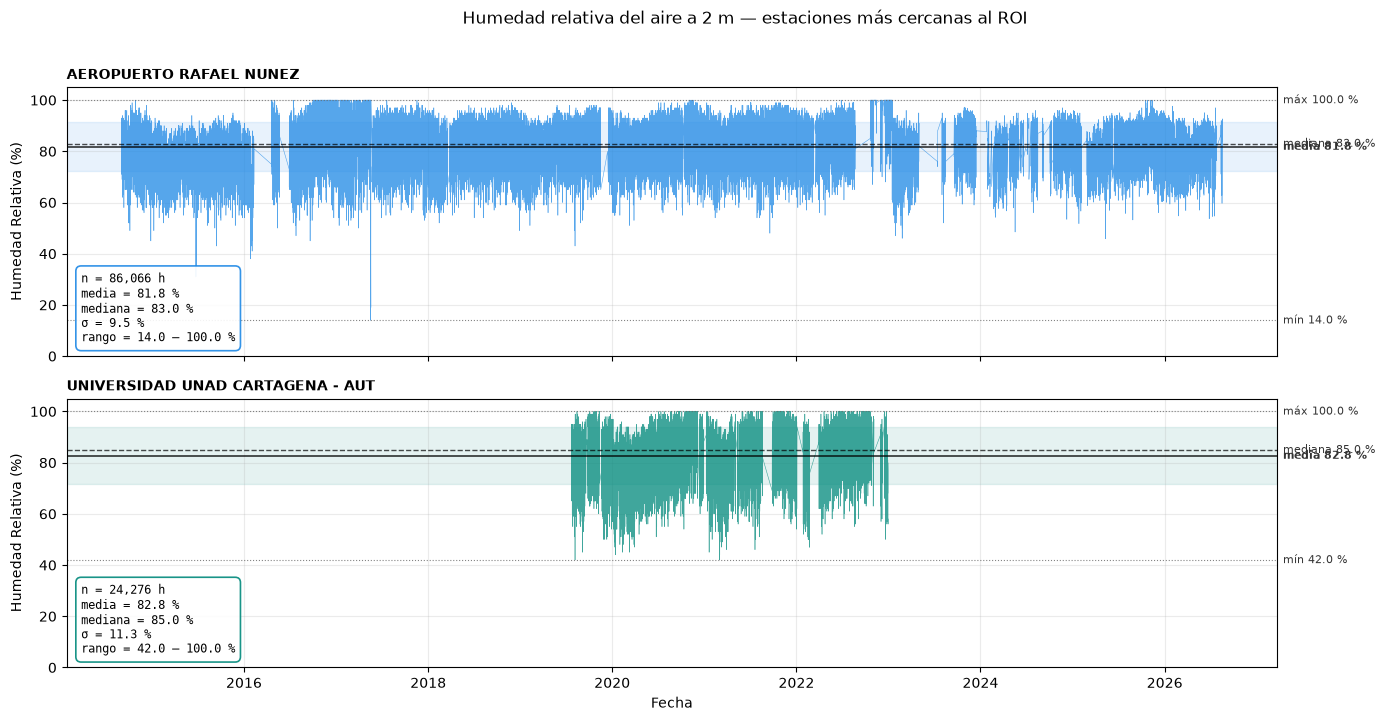

In [16]:
PALETA = ["#1E88E5", "#00897B", "#D81B60", "#F4511E"]
nombres = horaria["Estacion"].drop_duplicates().tolist()

stats = (
    horaria.groupby("Estacion")["humedad"]
    .agg(n="size", media="mean", mediana="median", std="std", minimo="min", maximo="max")
    .round(2)
    .reindex(nombres)
)
display(stats)

fig, axes = plt.subplots(len(nombres), 1, figsize=(15, 3.6 * len(nombres)),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, nombre, color in zip(axes, nombres, PALETA):
    sub = horaria[horaria["Estacion"] == nombre]
    s = stats.loc[nombre]

    ax.plot(sub["FechaObservacion"], sub["humedad"], lw=0.4, alpha=0.75, color=color)

    # Bandas y líneas de referencia
    ax.axhspan(s["media"] - s["std"], s["media"] + s["std"],
               color=color, alpha=0.10, zorder=0)
    ax.axhline(s["media"], color="black", lw=1.2, ls="-", alpha=0.8)
    ax.axhline(s["mediana"], color="black", lw=1.0, ls="--", alpha=0.7)
    ax.axhline(s["minimo"], color="#666", lw=0.8, ls=":", alpha=0.8)
    ax.axhline(s["maximo"], color="#666", lw=0.8, ls=":", alpha=0.8)

    for val, txt, peso in [
        (s["media"],   f'media {s["media"]:.1f} %',   "bold"),
        (s["mediana"], f'mediana {s["mediana"]:.1f} %', "normal"),
        (s["minimo"],  f'mín {s["minimo"]:.1f} %',    "normal"),
        (s["maximo"],  f'máx {s["maximo"]:.1f} %',    "normal"),
    ]:
        ax.annotate(txt, xy=(1.0, val), xycoords=("axes fraction", "data"),
                    xytext=(4, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=8, fontweight=peso, color="#333")

    caja = (f'n = {int(s["n"]):,} h\n'
            f'media = {s["media"]:.1f} %\n'
            f'mediana = {s["mediana"]:.1f} %\n'
            f'σ = {s["std"]:.1f} %\n'
            f'rango = {s["minimo"]:.1f} – {s["maximo"]:.1f} %')
    ax.text(0.012, 0.04, caja, transform=ax.transAxes, fontsize=8.5,
            va="bottom", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      edgecolor=color, alpha=0.9, linewidth=1.2))

    ax.set_title(nombre, fontsize=10, loc="left", fontweight="bold")
    ax.set_ylabel("Humedad Relativa (%)")
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Humedad relativa del aire a 2 m — estaciones más cercanas al ROI",
             fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 0.93, 0.98])
plt.show()

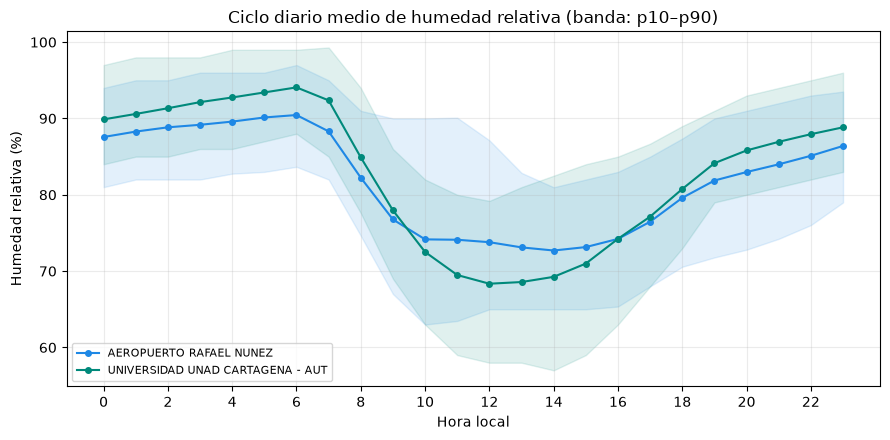

In [17]:
# Ciclo diario medio: variación horaria de la humedad relativa
ciclo = (
    horaria.assign(hora=horaria["FechaObservacion"].dt.hour)
    .groupby(["Estacion", "hora"])["humedad"]
    .agg(
        media="mean",
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90),
    )
    .round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre, color in zip(nombres, PALETA):
    s = ciclo[ciclo["Estacion"] == nombre]
    ax.plot(s["hora"], s["media"], marker="o", ms=4, color=color, label=nombre[:34])
    ax.fill_between(s["hora"], s["p10"], s["p90"], color=color, alpha=0.12)

ax.set_xlabel("Hora local")
ax.set_ylabel("Humedad relativa (%)")
ax.set_title("Ciclo diario medio de humedad relativa (banda: p10–p90)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Limitaciones a declarar en el manuscrito

**Ausencia de estaciones en el área de estudio.** La estación más próxima está a ~8.96 km del borde del ROI (Aeropuerto Rafael Núñez).
**Sesgo espacial y representatividad.** Rafael Núñez es una estación aeroportuaria sobre pista/asfalto y UNAD es urbana. Ambas sirven para dinámicas sinópticas regionales, aunque sobre el espejo de agua de la laguna la evaporación local puede sostener humedades relativas ligeramente superiores durante las horas de insolación máxima.
**Heterogeneidad de muestreo.** Se recomienda emplear la serie horaria u homogeneizada para cualquier análisis comparativo.